# 🧠 Intuition Companion - Phase 0

This notebook is the **"why"** behind the concepts. Analogies, real-world examples, and visualizations to make things click.

Use alongside the main notebooks when you want deeper understanding.

---
## 1. Linear vs Non-Linear: Why It Matters

### What is "linear"?

Linear means: **output changes proportionally to input. No curves, no surprises.**

```
y = 2x + 3
```

If you double x, the output changes predictably. Graph it → straight line. Always.

**Real world examples of linear:**
- Converting currency (€1 = $1.08, always the same ratio)
- Distance = speed × time (constant speed)
- Buying apples: 5 apples cost 5× what 1 apple costs

---

### What is "non-linear"?

Non-linear means: **the relationship has curves, thresholds, or surprises.**

**Real world examples:**
- Virus spread (1 person infects 2, who infect 4, who infect 8... exponential)
- Sound volume perception (doubling watts doesn't sound twice as loud)
- Water boiling (heating from 90°→99° does nothing visible, then 99°→100° → dramatic change)

---

### Why can't linear math recognize a cat?

A linear function can only draw **straight lines** to separate things.

```
Linear thinking: "If pixel_152 > 0.5 AND pixel_89 < 0.3 → cat"
                 (just straight cuts through the data)
```

But "cat vs not cat" isn't separable by straight lines. Cats can be black, white, sitting, jumping, rotated, zoomed...

**You need curves.** You need the model to learn complex boundaries.

---

### What does "stacking layers" mean?

A layer is just: `output = input × weights + bias`

If you stack two layers without activation:

```
layer1 = input × W1 + b1
layer2 = layer1 × W2 + b2
```

Expand it:

```
layer2 = (input × W1 + b1) × W2 + b2
       = input × (W1 × W2) + (b1 × W2 + b2)
       = input × W_combined + b_combined
```

**It collapses to one layer.** No matter how many you stack, it's still just `input × something + something`. Still a straight line. Still can't recognize a cat.

---

### What activation functions actually do

They add a **kink, bend, or curve** between layers.

```
layer1 = ReLU(input × W1 + b1)    ← non-linear break here
layer2 = ReLU(layer1 × W2 + b2)   ← and here
```

Now it **can't collapse**. Each layer can learn a different "bend" in the function. Stack enough bends → you can approximate any curve → you can learn complex patterns like "cat."

---

### Analogy: Folding paper

**Linear only:** You have a flat sheet of paper. You can stretch it, shrink it, tilt it. But it stays flat. You can only separate things that are already separable by a straight cut.

**With activation (non-linear):** You can **fold** the paper. Now points that were far apart are close together. Points that were close are far apart. Complex patterns become separable.

Each layer = one fold. More layers = more folds = more complex shapes you can carve out.

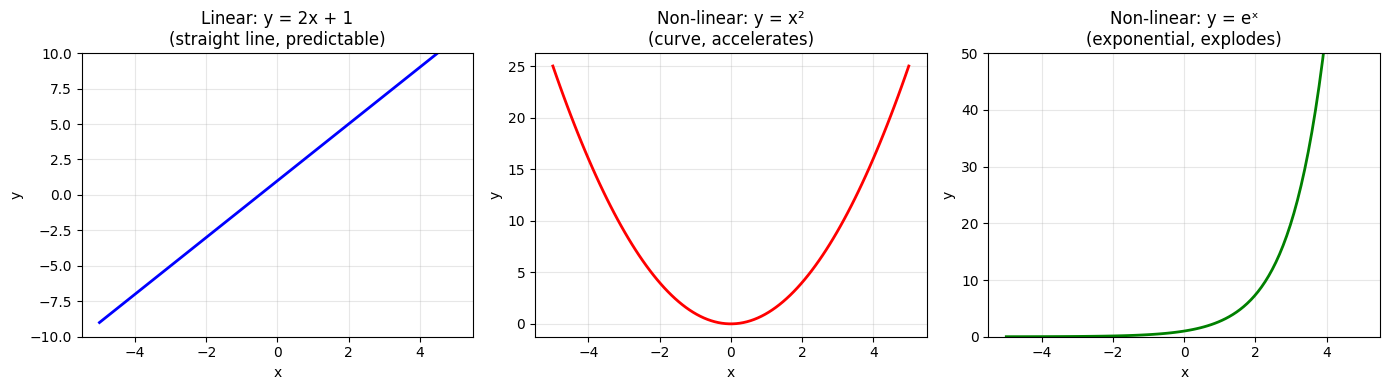

In [1]:
# Let's visualize linear vs non-linear
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)

# Linear function
y_linear = 2 * x + 1

# Non-linear functions
y_quadratic = x ** 2
y_exponential = np.exp(x)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(x, y_linear, 'b-', linewidth=2)
axes[0].set_title('Linear: y = 2x + 1\n(straight line, predictable)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-10, 10)

axes[1].plot(x, y_quadratic, 'r-', linewidth=2)
axes[1].set_title('Non-linear: y = x²\n(curve, accelerates)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].grid(True, alpha=0.3)

axes[2].plot(x, y_exponential, 'g-', linewidth=2)
axes[2].set_title('Non-linear: y = eˣ\n(exponential, explodes)')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 50)

plt.tight_layout()
plt.show()

---
## 2. Activation Functions: Real-World Intuition

### What is an activation function?

It's a decision gate between layers. Each neuron computes a number, and the activation function decides: "Should this signal pass through? How much?"

---

### ReLU (Rectified Linear Unit)

"Rectified" = corrected/adjusted. "Linear" = straight line.  
So ReLU is a "corrected straight line" — linear for positives, flat zero for negatives.

```
If x < 0  →  output 0
If x ≥ 0  →  output x (unchanged)
```

*Analogy — One-way water valve:*
- Water pushing forward (positive) → flows through normally
- Water pushing backward (negative) → valve blocks it, zero flow

*Analogy — Hiring committee:*
- 10 people score a candidate from -10 to +10
- Without ReLU: you average all scores. One very negative person (-10) tanks a good candidate.
- With ReLU: negative scores become 0. You're measuring "how much support?" not "net opinion"

---

### Sigmoid

Squashes any number into 0-1 range. Good for "probability" or "confidence."

*Analogy — Confidence percentage:*
- Input: -10 → Output: ~0% (definitely no)
- Input: 0 → Output: 50% (unsure)
- Input: +10 → Output: ~100% (definitely yes)

*Analogy — Dimmer switch:*
- Gradually transitions from "off" to "on"
- Never fully off, never fully on, but smoothly in between

---

### Tanh (Hyperbolic Tangent)

Like sigmoid but outputs -1 to +1 instead of 0 to 1.

*Analogy — Opinion scale:*
- -1 = strongly disagree
- 0 = neutral
- +1 = strongly agree

---

### Softmax

Takes multiple numbers and converts them into probabilities that **sum to 1**.

*Analogy — Election results:*
- Raw votes: Candidate A got 100, B got 50, C got 50
- Softmax converts to: A = 50%, B = 25%, C = 25%
- Always sums to 100%, always positive

*Analogy — Confidence distribution:*
- You ask: "Is this pixel bone, muscle, or background?"
- Network outputs raw scores: [2.0, 1.0, 0.5]
- Softmax converts to probabilities: [57%, 26%, 17%]
- Answer: "57% confident it's bone"

*Why it matters for segmentation:*
- Each pixel must be classified as ONE thing (vertebra, disc, background, etc.)
- Softmax ensures the model commits — probabilities must sum to 1
- You can't say "80% vertebra AND 80% disc" — that's 160%, makes no sense
- Softmax forces a proper distribution

---

### What's used in practice

| Where | Function | Why |
|-------|----------|-----|
| Hidden layers | ReLU (or GELU, SiLU) | Fast, gradients don't vanish |
| Binary output (yes/no) | Sigmoid | Need probability 0-1 |
| Multi-class output | Softmax | Probabilities that sum to 1 |
| Older RNNs/LSTMs | Tanh | Historical, works well for sequences |

---

### Why not Sigmoid/Tanh everywhere?

They suffer from **vanishing gradients**: when values get very large or small, the gradient becomes tiny (~0.0001). Training uses gradients to update weights — tiny gradient means weights barely change, learning stops.

ReLU gradient is always 1 for positive values. No vanishing.

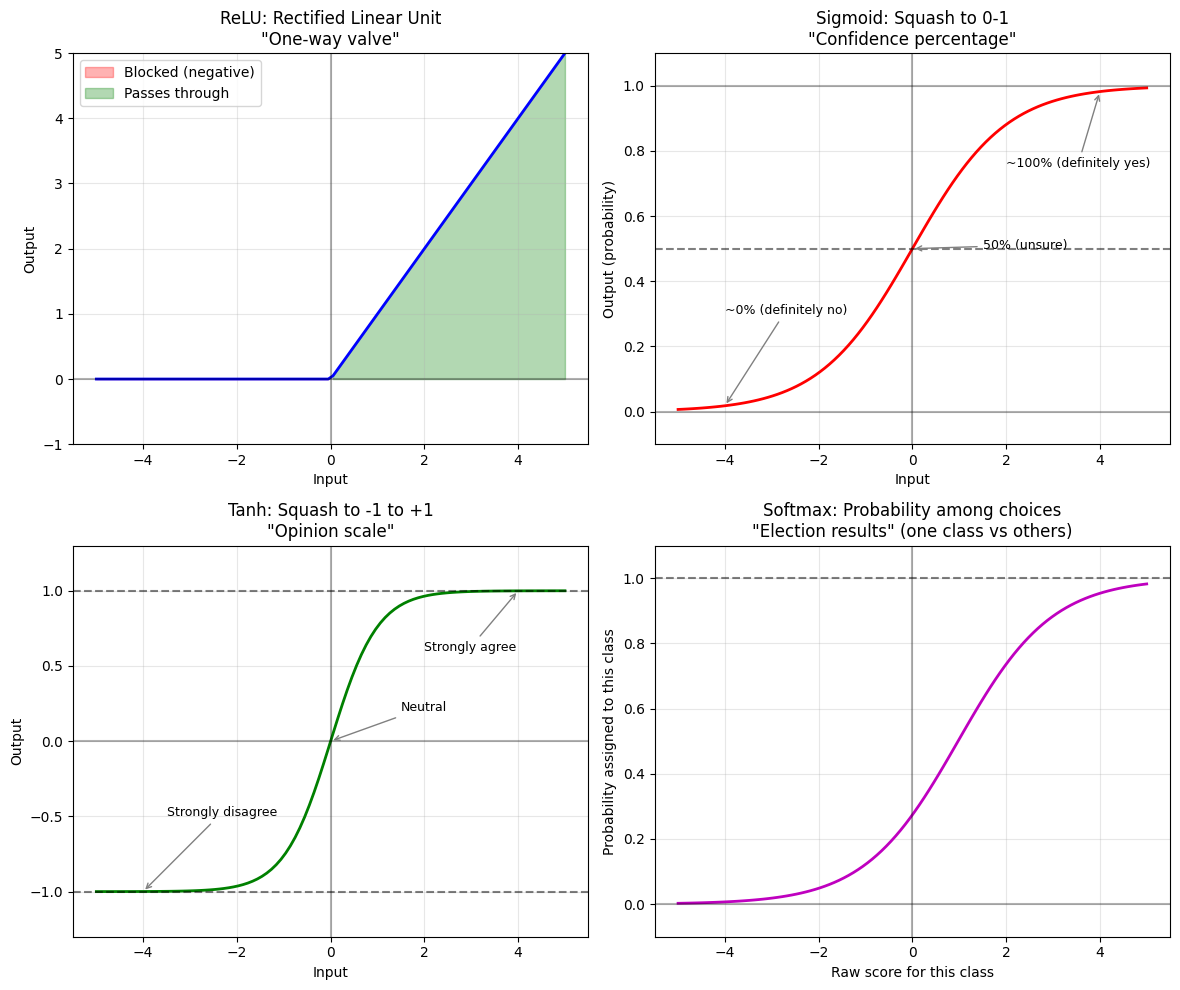

In [2]:
# Visualize all activation functions
import numpy as np
import matplotlib.pyplot as plt

def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def softmax(x):
    # For visualization, we'll show softmax on a single value against two fixed values
    # This shows how one class probability changes as its raw score changes
    exp_x = np.exp(x)
    exp_others = np.exp(0) + np.exp(0.5)  # two other fixed classes
    return exp_x / (exp_x + exp_others)

x = np.linspace(-5, 5, 100)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# ReLU
axes[0, 0].plot(x, relu(x), 'b-', linewidth=2)
axes[0, 0].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[0, 0].axvline(x=0, color='k', linestyle='-', alpha=0.3)
axes[0, 0].fill_between(x, relu(x), where=(x < 0), alpha=0.3, color='red', label='Blocked (negative)')
axes[0, 0].fill_between(x, relu(x), where=(x >= 0), alpha=0.3, color='green', label='Passes through')
axes[0, 0].set_title('ReLU: Rectified Linear Unit\n"One-way valve"', fontsize=12)
axes[0, 0].set_xlabel('Input')
axes[0, 0].set_ylabel('Output')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim(-1, 5)

# Sigmoid
axes[0, 1].plot(x, sigmoid(x), 'r-', linewidth=2)
axes[0, 1].axhline(y=0.5, color='k', linestyle='--', alpha=0.5)
axes[0, 1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[0, 1].axhline(y=1, color='k', linestyle='-', alpha=0.3)
axes[0, 1].axvline(x=0, color='k', linestyle='-', alpha=0.3)
axes[0, 1].set_title('Sigmoid: Squash to 0-1\n"Confidence percentage"', fontsize=12)
axes[0, 1].set_xlabel('Input')
axes[0, 1].set_ylabel('Output (probability)')
axes[0, 1].set_ylim(-0.1, 1.1)
axes[0, 1].grid(True, alpha=0.3)
# Add annotations
axes[0, 1].annotate('~0% (definitely no)', xy=(-4, sigmoid(-4)), xytext=(-4, 0.3),
                    arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)
axes[0, 1].annotate('50% (unsure)', xy=(0, 0.5), xytext=(1.5, 0.5),
                    arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)
axes[0, 1].annotate('~100% (definitely yes)', xy=(4, sigmoid(4)), xytext=(2, 0.75),
                    arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)

# Tanh
axes[1, 0].plot(x, tanh(x), 'g-', linewidth=2)
axes[1, 0].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[1, 0].axhline(y=-1, color='k', linestyle='--', alpha=0.5)
axes[1, 0].axhline(y=1, color='k', linestyle='--', alpha=0.5)
axes[1, 0].axvline(x=0, color='k', linestyle='-', alpha=0.3)
axes[1, 0].set_title('Tanh: Squash to -1 to +1\n"Opinion scale"', fontsize=12)
axes[1, 0].set_xlabel('Input')
axes[1, 0].set_ylabel('Output')
axes[1, 0].set_ylim(-1.3, 1.3)
axes[1, 0].grid(True, alpha=0.3)
# Add annotations
axes[1, 0].annotate('Strongly disagree', xy=(-4, tanh(-4)), xytext=(-3.5, -0.5),
                    arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)
axes[1, 0].annotate('Neutral', xy=(0, 0), xytext=(1.5, 0.2),
                    arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)
axes[1, 0].annotate('Strongly agree', xy=(4, tanh(4)), xytext=(2, 0.6),
                    arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)

# Softmax visualization
axes[1, 1].plot(x, softmax(x), 'm-', linewidth=2)
axes[1, 1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[1, 1].axhline(y=1, color='k', linestyle='--', alpha=0.5)
axes[1, 1].axvline(x=0, color='k', linestyle='-', alpha=0.3)
axes[1, 1].set_title('Softmax: Probability among choices\n"Election results" (one class vs others)', fontsize=12)
axes[1, 1].set_xlabel('Raw score for this class')
axes[1, 1].set_ylabel('Probability assigned to this class')
axes[1, 1].set_ylim(-0.1, 1.1)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
# Softmax in action: see how probabilities always sum to 1
import numpy as np

def softmax(x):
    exp_x = np.exp(x - np.max(x))  # subtract max for numerical stability
    return exp_x / exp_x.sum()

# Scenario: Is this pixel bone, muscle, or background?
classes = ['Bone', 'Muscle', 'Background']

print("=" * 50)
print("SOFTMAX IN ACTION: Pixel Classification")
print("=" * 50)

# Example 1: Network is confident it's bone
raw_scores_1 = np.array([4.0, 1.0, 0.5])
probs_1 = softmax(raw_scores_1)
print("\nExample 1: Network thinks it's bone")
print(f"Raw scores:   {dict(zip(classes, raw_scores_1))}")
print(f"Probabilities: {dict(zip(classes, [f'{p:.1%}' for p in probs_1]))}")
print(f"Sum of probabilities: {probs_1.sum():.4f}")

# Example 2: Network is unsure between bone and muscle
raw_scores_2 = np.array([2.0, 1.8, 0.2])
probs_2 = softmax(raw_scores_2)
print("\nExample 2: Network is unsure (bone vs muscle)")
print(f"Raw scores:   {dict(zip(classes, raw_scores_2))}")
print(f"Probabilities: {dict(zip(classes, [f'{p:.1%}' for p in probs_2]))}")
print(f"Sum of probabilities: {probs_2.sum():.4f}")

# Example 3: Network is very confident it's background
raw_scores_3 = np.array([-1.0, 0.5, 5.0])
probs_3 = softmax(raw_scores_3)
print("\nExample 3: Network thinks it's background")
print(f"Raw scores:   {dict(zip(classes, raw_scores_3))}")
print(f"Probabilities: {dict(zip(classes, [f'{p:.1%}' for p in probs_3]))}")
print(f"Sum of probabilities: {probs_3.sum():.4f}")

print("\n" + "=" * 50)
print("KEY INSIGHT: Probabilities ALWAYS sum to 1 (100%)")
print("The model must commit to a distribution!")
print("=" * 50)

SOFTMAX IN ACTION: Pixel Classification

Example 1: Network thinks it's bone
Raw scores:   {'Bone': 4.0, 'Muscle': 1.0, 'Background': 0.5}
Probabilities: {'Bone': '92.6%', 'Muscle': '4.6%', 'Background': '2.8%'}
Sum of probabilities: 1.0000

Example 2: Network is unsure (bone vs muscle)
Raw scores:   {'Bone': 2.0, 'Muscle': 1.8, 'Background': 0.2}
Probabilities: {'Bone': '50.4%', 'Muscle': '41.3%', 'Background': '8.3%'}
Sum of probabilities: 1.0000

Example 3: Network thinks it's background
Raw scores:   {'Bone': -1.0, 'Muscle': 0.5, 'Background': 5.0}
Probabilities: {'Bone': '0.2%', 'Muscle': '1.1%', 'Background': '98.7%'}
Sum of probabilities: 1.0000

KEY INSIGHT: Probabilities ALWAYS sum to 1 (100%)
The model must commit to a distribution!


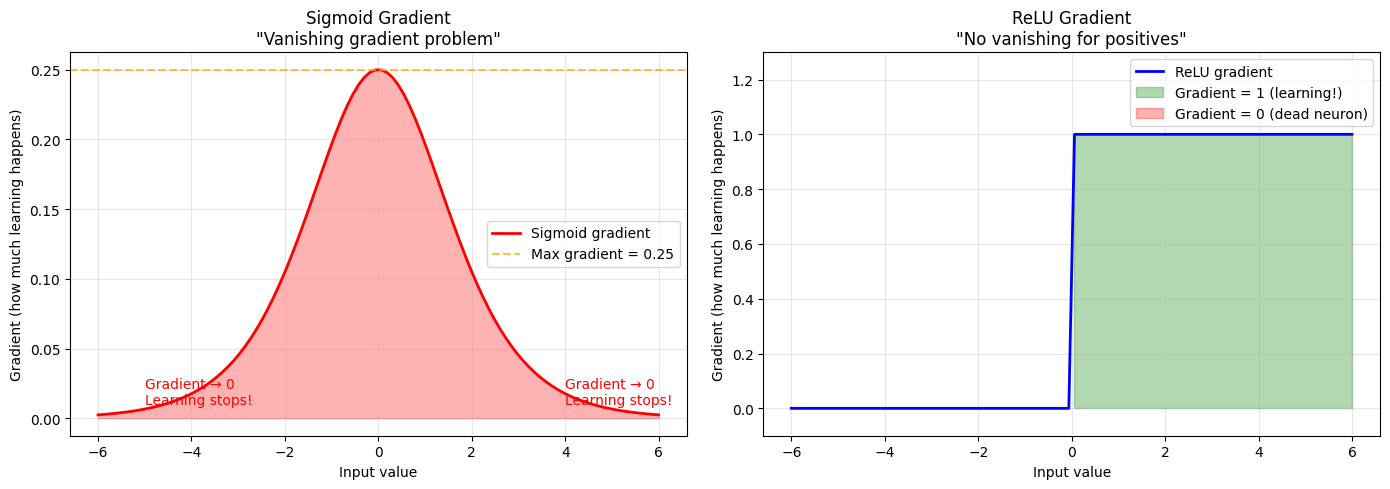


WHY THIS MATTERS:

Sigmoid: Max gradient is 0.25. After many layers, gradients
         multiply: 0.25 × 0.25 × 0.25 = 0.015 (almost zero!)
         → Early layers barely learn anything.

ReLU:    Gradient is 1 for positive values.
         1 × 1 × 1 = 1 (stays strong!)
         → All layers can learn effectively.


In [4]:
# Vanishing gradient problem: why ReLU wins
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_gradient(x):
    s = sigmoid(x)
    return s * (1 - s)

def relu_gradient(x):
    return np.where(x > 0, 1, 0)

x = np.linspace(-6, 6, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sigmoid gradient
axes[0].plot(x, sigmoid_gradient(x), 'r-', linewidth=2, label='Sigmoid gradient')
axes[0].axhline(y=0.25, color='orange', linestyle='--', alpha=0.7, label='Max gradient = 0.25')
axes[0].fill_between(x, sigmoid_gradient(x), alpha=0.3, color='red')
axes[0].set_title('Sigmoid Gradient\n"Vanishing gradient problem"', fontsize=12)
axes[0].set_xlabel('Input value')
axes[0].set_ylabel('Gradient (how much learning happens)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].annotate('Gradient → 0\nLearning stops!', xy=(-5, 0.01), fontsize=10, color='red')
axes[0].annotate('Gradient → 0\nLearning stops!', xy=(4, 0.01), fontsize=10, color='red')

# ReLU gradient
axes[1].plot(x, relu_gradient(x), 'b-', linewidth=2, label='ReLU gradient')
axes[1].fill_between(x, relu_gradient(x), where=(x > 0), alpha=0.3, color='green', label='Gradient = 1 (learning!)')
axes[1].fill_between(x, relu_gradient(x), where=(x <= 0), alpha=0.3, color='red', label='Gradient = 0 (dead neuron)')
axes[1].set_title('ReLU Gradient\n"No vanishing for positives"', fontsize=12)
axes[1].set_xlabel('Input value')
axes[1].set_ylabel('Gradient (how much learning happens)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-0.1, 1.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("WHY THIS MATTERS:")
print("=" * 60)
print("\nSigmoid: Max gradient is 0.25. After many layers, gradients")
print("         multiply: 0.25 × 0.25 × 0.25 = 0.015 (almost zero!)")
print("         → Early layers barely learn anything.")
print("\nReLU:    Gradient is 1 for positive values.")
print("         1 × 1 × 1 = 1 (stays strong!)")
print("         → All layers can learn effectively.")
print("=" * 60)

---
## 3. More topics...

*This section will grow as you ask more questions!*

Future topics might include:
- Loss functions intuition
- Backpropagation visualized
- Why batch size matters
- Learning rate intuition
- Overfitting vs underfitting
- ...